## Import Dependencies

In [ ]:
import os
import random
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse
from torch_geometric.nn import global_mean_pool, global_max_pool, Set2Set
from torch_geometric.nn import NNConv, CGConv, GCNConv, GATConv, GATv2Conv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN
from pymatgen.util import coord as puc
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize.plot import plot_atoms
from pymatgen.analysis.graphs import StructureGraph


from graphy_cvae import get_full_defective, get_nodes, get_edges, get_features
from graphy_cvae import get_mask, get_globals, get_cloud, get_graphs, get_target_tensor

## Data Prep

In [ ]:
# The whole dataset
comb_df = pd.read_csv(f"Final_Dataset/combined/combined_data.csv")
# sample_df = comb_df.sample(10, random_state=42)

# Sample row
an_index = random.randint(0, len(comb_df)-1)
a_row = comb_df.iloc[an_index]
# sample_row = sample_df.iloc[0]

# Get required attributes from sample row
a_dataset_material = a_row["dataset_material"]
a_material = a_dataset_material.split("_")[1]
an_id = a_row["_id"]
a_bgv = a_row["band_gap_value"]

# Get defective structure
a_defective_file_path = f"original_dataset/{a_dataset_material}/cifs/{an_id}.cif"
a_defective_structure = Structure.from_file(a_defective_file_path)

# Get reference structure
a_ref_file_path = f"Final_Dataset/ref_cifs/{a_dataset_material}.cif"
a_reference_structure = Structure.from_file(a_ref_file_path)

a_full_defective_structure  = get_full_defective(a_reference_structure, a_defective_structure)
a_full_defective_nodes      = get_nodes(a_full_defective_structure)
a_full_defective_edges      = get_edges(a_full_defective_structure)
a_full_defective_E_features = get_features(a_full_defective_edges, a_full_defective_structure)
a_full_defective_mask       = get_mask(a_reference_structure)
a_full_defective_u          = get_globals(a_material, a_bgv)
a_full_defective_target     = get_target_tensor(a_full_defective_structure)

## Implimentation on the whole dataset

In [ ]:
# ================================
# WHOLE DATA
# ================================
'''
train_set, val_set = train_test_split(comb_df, test_size=0.3, random_state=42, stratify=comb_df["strata"])

train_graphs = get_graphs(train_set)
val_graphs = get_graphs(val_set)

torch.save(train_graphs, "Final_Dataset/cvae models/cvae_train_graphs.pt")
torch.save(val_graphs, "Final_Dataset/cvae models/cvae_val_graphs.pt")
'''
# ===============================
# HIGH DATASET ONLY
# ===============================
'''
sample_df = comb_df[(comb_df["dataset_material"] != "low_MoS2") & (comb_df["dataset_material"] != "low_WSe2")]

print(len(sample_df))

sample_train, sample_val = train_test_split(sample_df, test_size=0.25, random_state=42, stratify=sample_df["strata"])

sample_train_graphs = get_graphs(sample_train)
sample_val_graphs = get_graphs(sample_val)

# torch.save(sample_train_graphs, f"Final_Dataset/cvae models/high_cvae_train_graphs.pt")
# torch.save(sample_val_graphs, f"Final_Dataset/cvae models/high_cvae_val_graphs.pt")
'''

# =============================
# HIGH MoS2 & HIGH WSe2
# =============================

'''
high_mos2_df = comb_df[comb_df["dataset_material"] == "high_MoS2"]


sample_train, sample_val = train_test_split(high_mos2_df, test_size=0.25, random_state=42, stratify=high_mos2_df["strata"])

sample_train_graphs = get_graphs(sample_train)
sample_val_graphs = get_graphs(sample_val)

# torch.save(sample_train_graphs, "Final_Dataset/cvae models/high_cvae_train_graphs.pt")
# torch.save(sample_val_graphs, "Final_Dataset/cvae models/high_cvae_val_graphs.pt")
'''

## More Data Manipulations

In [ ]:
def get_pristine_edges(structure):
    # 2. Generate a StructureGraph using a neighbor strategy (e.g., CrystalNN)
    mdnn = MinimumDistanceNN()
    the_graph = StructureGraph.with_local_env_strategy(structure, mdnn)

    # 3. Extract edge indices (COO format: [source_indices, target_indices])
    edge_indices = []
    for u, v, _ in the_graph.graph.edges(data=True):
        edge_indices.append([u, v])
        edge_indices.append([v, u])

    edge_indices = np.array(edge_indices).T  # Shape: (2, num_edges)
    return edge_indices

In [ ]:
def get_site_features(structure):
    # all_coords = structure.cart_coords  # .get_fractional_coords(defective_struct.cart_coords)
    # print(all_coords)
    all_features= []
    for a_site in structure.sites:
        site = a_site.specie

        coords = a_site.coords
        p_Z = site.Z
        p_X = site.X
        p_ar = site.atomic_radius
        p_row = site.row
        p_group = site.group
        p_ea = site.electron_affinity
        p_cos = max(site.common_oxidation_states)

        site_features = np.concatenate((coords, np.array([p_Z, p_X, p_ar, p_row, p_group, p_ea, p_cos])))

        all_features.append(site_features)

    return all_features

BN_features = get_site_features(Structure.from_file("Final_Dataset/ref_cifs/high_BN.cif"))

In [ ]:
def get_pristine_mask(structure):
    masking_dict = {
        "Ga":"In", "Se":"S", "In":"Ga", 
        "B":"C", "N":"C", "P":"N", 
        "W":"Mo", "Mo":"W", "S":"Se"
    }

    the_masks = []

    for site in structure.sites:
        specie_now = site.specie.symbol

        # Normal site 
        norm = site.specie.Z

        # Vacancy site
        vac = 0

        # Sub site
        allowed_sub = masking_dict[specie_now]
        sub = Element(allowed_sub).Z

        # The row mask
        row_mask = [norm, vac, sub]
        
        the_masks.append(row_mask)

    
    return the_masks

GaSe_mask = get_pristine_mask(Structure.from_file("Final_Dataset/ref_cifs/high_GaSe.cif"))


In [ ]:
# Load graphs
# full_train_graphs = torch.load("Final_Dataset/cvae graphs/cvae_train_graphs.pt", weights_only=False)
# full_val_graphs = torch.load("Final_Dataset/cvae graphs/cvae_val_graphs.pt", weights_only=False)

high_train_graphs = torch.load("Final_Dataset/cvae graphs/high_cvae_train_graphs.pt", weights_only=False)
high_val_graphs = torch.load("Final_Dataset/cvae graphs/high_cvae_val_graphs.pt", weights_only=False)

# subset_indices = torch.randperm(2000)[:600]
# train_sub_dataset = torch.utils.data.Subset(high_train_graphs, subset_indices)

def add_bond_batch(graph):
    for data in graph:
        bond_batch = torch.zeros((1, data.edge_index.shape[1]))
        data.bond_batch = bond_batch.squeeze(0).to(dtype=torch.long)

    return graph

def add_pristine_edges(graph):
    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]

    all_pristine_edges = []
    for material in materials:
        structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{material}.cif")

        edge_indices = get_pristine_edges(structure)
        
        all_pristine_edges.append(edge_indices)

    for data in graph:
        # Get index with 1 in the first 6 global attributes
        one_hot = data.u[0, :6]
        the_index = torch.argmax(one_hot)
        data.pristine_edges = torch.tensor(all_pristine_edges[the_index], dtype=torch.long)

    return graph

def add_pristine_site_features(graph):
    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]

    all_pristine_features = []
    for material in materials:
        structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{material}.cif")

        p_features = get_site_features(structure)
        
        all_pristine_features.append(p_features)

    for data in graph:
        # Get index with 1 in the first 6 global attributes
        one_hot = data.u[0, :6]
        the_index = torch.argmax(one_hot)
        data.pristine_features = torch.tensor(all_pristine_features[the_index], dtype=torch.float)

    return graph

def add_new_mask(graph):
    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]

    all_masks = []
    for material in materials:
        structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{material}.cif")

        new_mask = get_pristine_mask(structure)
        
        all_masks.append(new_mask)

    for data in graph:
        # Get index with 1 in the first 6 global attributes
        one_hot = data.u[0, :6]
        the_index = torch.argmax(one_hot)
        data.pristine_mask = torch.tensor(all_masks[the_index], dtype=torch.long)

    return graph

def add_num_defects(graph):
    for data in graph:
        num_defects = data.y[:, :1].squeeze(-1).to(dtype=torch.float).sum()
        data.num_defects = num_defects.reshape((1,1))
    return graph
        

new_high_train_graphs = add_bond_batch(high_train_graphs)
new_high_val_graphs = add_bond_batch(high_val_graphs)

new_high_train_graphs = add_pristine_edges(new_high_train_graphs)
new_high_val_graphs = add_pristine_edges(new_high_val_graphs)

new_high_train_graphs = add_pristine_site_features(new_high_train_graphs)
new_high_val_graphs = add_pristine_site_features(new_high_val_graphs)


new_high_train_graphs = add_new_mask(new_high_train_graphs)
new_high_val_graphs = add_new_mask(new_high_val_graphs)

new_high_train_graphs = add_num_defects(new_high_train_graphs)
new_high_val_graphs = add_num_defects(new_high_val_graphs)

class FeatureScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, graphs, attr):
        all_vals = torch.cat([getattr(g, attr) for g in graphs], dim=0)
        self.mean = all_vals.mean(dim=0, keepdim=True)
        self.std = all_vals.std(dim=0, keepdim=True) + 1e-8
        return self

    def transform(self, graphs, attr):
        for g in graphs:
            setattr(g, attr, (getattr(g, attr) - self.mean) / self.std)
        return graphs

    
x_scaler = FeatureScaler().fit(new_high_train_graphs, "x")
edge_scaler = FeatureScaler().fit(new_high_train_graphs, "edge_attr")
u_scaler = FeatureScaler().fit(new_high_train_graphs, "u")

new_graphs = []

for split in [new_high_train_graphs, new_high_val_graphs]:
    split = x_scaler.transform(split, "x")
    split = edge_scaler.transform(split, "edge_attr")
    split = u_scaler.transform(split, "u")
    new_graphs.append(split)

new_high_train_graphs = new_graphs[0]
new_high_val_graphs = new_graphs[1]
# test_graphs = new_graphs[2]

# Create data loaders
# full_train_loader = DataLoader(full_train_graphs, batch_size=1, shuffle=True) 
# full_val_loader   = DataLoader(full_val_graphs, batch_size=1, shuffle=False)

high_train_loader = DataLoader(new_high_train_graphs, batch_size=1, shuffle=True) 
high_val_loader   = DataLoader(new_high_val_graphs, batch_size=1, shuffle=False)
# high_train_loader = DataLoader(train_sub_dataset, batch_size=1, shuffle=True)
# high_val_loader   = DataLoader(high_val_graphs, batch_size=1, shuffle=False)


# Visualize the shape of the data
'''for batch in full_train_loader:
    print(f"Full data sample: {batch}")
    break'''

for batch in high_train_loader:
    print(f"High data sample: {batch}")
    break

In [ ]:
# sample_0 = full_train_loader.dataset[0]
sample_0 = high_train_loader.dataset[0]

NODE_DIM   = sample_0.x.shape[1] 
EDGE_DIM   = sample_0.edge_attr.shape[1] 
U_DIM      = sample_0.u.shape[1] 
MASK_DIM   = sample_0.mask.shape[0]
TARGET_DIM = sample_0.y.shape[1]

HIDDEN_DIM = 256
LATENT_DIM = 32

print(f"Node dim: {NODE_DIM}\nEdge dim: {EDGE_DIM}\nU dim: {U_DIM}\nMask Dim: {MASK_DIM}\nTarget Dim: {TARGET_DIM}")

In [ ]:
def target_look(mask, true_z=None, bool_site=None):
    if true_z is not None:
        bool_site = (mask == true_z[:, None]).int().argmax(dim=1)
        return bool_site.to(true_z.device)
    elif bool_site is not None:
        the_true_z = mask[torch.arange(len(bool_site)), bool_site]
        return the_true_z.to(bool_site.device)

    

    
for sample_0 in high_train_loader:
    # print(sample_0)
    sample_y = sample_0.y

    # sample_sites = sample_y[:, :1]
    # sample_sites = sample_sites.squeeze(-1).to(dtype=torch.long)

    sample_species = torch.argmax(sample_y[:, 1:], dim=1)
    # target_look = (sample_0.pristine_mask == sample_species[:, None]).int().argmax(dim=1)
    the_target_look = target_look(sample_0.pristine_mask, true_z=sample_species)
    the_true_z = target_look(sample_0.pristine_mask, bool_site=the_target_look)

    # print(sample_sites.shape)
    # print(sample_sites)
    # print(sample_species.shape)
    # print(sample_species)
    print(the_target_look)
    # print(the_true_z)
    vac_list = torch.tensor([0,1,0])[the_target_look]
    sub_list = torch.tensor([0,0,1])[the_target_look]

    print(vac_list)
    print(sub_list)

    
    # print(torch.argmax(sample_species, dim=1))

    # sample_sites = sample_sites.reshape(1, sample_sites.shape[0])
    # print(sample_sites.to(dtype=torch.long))
    # sample_species = sample_species.squeeze(1)

    # print(sample_sites.shape)
    # print(sample_species.shape)


    break
## The model architecture

### Why the Variational Autoencoder?

This functions as a **true generative model**. Remember the goal is to be generate new materials, something the normal autoencoders fail at. 

The **conditional** part of the model is the fact that we are trying to **generate new defective structures** with a **desired band gap values**. 

To achieve this we concatenate the band gap as the label in the input data that will be passed in the encoder,  and with the latent vector that will be passed to the decoder. 

This ensures the model learns to generate structures specific to the band gap.

## Encoder

The encoder takes the defective structure and **learns the key features** of the structure and produces two vectors:

- Mean (μ): A central value representing the data.
- Standard Deviation (σ): It is a measure of how much the values can vary.

Why?
This is because the main goal is to produce a **latent representation** of the structure. 



In [ ]:
from torch_geometric.utils import scatter

class ShiftedSoftplus(nn.Module):
    def __init__(self):
        super().__init__()
        self.sp = nn.Softplus()
        self.shift = nn.Parameter(torch.log(torch.tensor([2.])), requires_grad=False)

    def forward(self, x):
        return self.sp(x) - self.shift

In [ ]:
# Encoder that looks like MEGNet

class EncoderBlock(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()

        self.phi_e = nn.Sequential(
            nn.Linear(4 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.phi_v = nn.Sequential(
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.phi_u = nn.Sequential(
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

    def forward(self, x, edge_index, edge_attr, u, batch, bond_batch):
        row, col = edge_index

        u_per_edge = u[bond_batch]
        edge_attr = self.phi_e(torch.cat([x[row], x[col], edge_attr, u_per_edge], dim=1))

        agg_edges = scatter(edge_attr, row, dim=0, dim_size=x.size(0), reduce='mean')
        u_per_node = u[batch]
        x = self.phi_v(torch.cat([agg_edges, x, u_per_node], dim=1))

        edge_pooled = global_mean_pool(edge_attr, bond_batch)
        node_pooled = global_mean_pool(x, batch)

        u = self.phi_u(torch.cat([edge_pooled, node_pooled, u], dim=1))

        return x, edge_attr, u


class EncoderPart(nn.Module):
    def __init__(self, node_dim, edge_dim, u_dim, embed_dim, num_blocks=3):
        super().__init__()
        self.nodes_mlp = nn.Sequential(
            nn.Linear(node_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )
        self.edge_attr_mlp = nn.Sequential(
            nn.Linear(edge_dim, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )
        self.u_mlp = nn.Sequential(
            nn.Linear(u_dim + 1, 2 * embed_dim), ShiftedSoftplus(),
            nn.Linear(2 * embed_dim, embed_dim), ShiftedSoftplus(),
        )

        self.blocks = nn.ModuleList([EncoderBlock(embed_dim) for _ in range(num_blocks)])

        self.set2set_x = Set2Set(embed_dim, processing_steps=3)
        self.set2set_edge_attr = Set2Set(embed_dim, processing_steps=3)

        self.readout = nn.Sequential(
            nn.Linear(5 * embed_dim, 4 * embed_dim), ShiftedSoftplus(),
            nn.Linear(4 * embed_dim, 3 * embed_dim), ShiftedSoftplus(),
            nn.Linear(3 * embed_dim, 2 * embed_dim), ShiftedSoftplus(),
        )

        self.mu_layer  = nn.Linear(2 * embed_dim, embed_dim)
        self.var_layer = nn.Linear(2 * embed_dim, embed_dim)

    def forward(self, data):
        x, edge_index, edge_attr, batch, u, bond_batch, num_defects = (
            data.x, data.edge_index, data.edge_attr, data.batch, data.u, data.bond_batch, data.num_defects
        )

        x = self.nodes_mlp(x)
        edge_attr = self.edge_attr_mlp(edge_attr)
        u = self.u_mlp(torch.cat([u, num_defects], dim=1))

        for block in self.blocks:
            x_new, edge_attr_new, u_new = block(x, edge_index, edge_attr, u, batch, bond_batch)
            # Residual connections: lets each block refine rather than overwrite,
            # and keeps gradients healthy through 3 stacked blocks
            x = x + x_new
            edge_attr = edge_attr + edge_attr_new
            u = u + u_new

        x_pool = self.set2set_x(x, batch)
        edge_pool = self.set2set_edge_attr(edge_attr, bond_batch)

        out = torch.cat([x_pool, edge_pool, u], dim=1)
        out = self.readout(out)
        
        mu  = self.mu_layer(out) 
        var = self.var_layer(out)
            
        return mu, var

the_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for the_sample in high_train_loader:
# for the_sample in full_train_loader:

    # the_sample = the_sample.to(the_device)

    MAX = the_sample.x.shape[0]

    # Test encoder
    test_encoder = EncoderPart(NODE_DIM, EDGE_DIM, U_DIM, embed_dim=32, num_blocks=3)
    out_mu, out_var = test_encoder(the_sample)
    print("TESTING ENCODER\n")
    
    print("Mu shape:", out_mu.shape)
    print("Mu sample:\n", out_mu)
    
    print("\nLog var shape:", out_var.shape)
    print("Log var Sample:\n", out_var)

    break


## Decoder

The decoder reconstructs/generates the data based on the latent space created

In [ ]:
def clean_decoder_target(sample_y, mask):
    sample_sites = sample_y[:, :1]
    sample_sites = sample_sites.squeeze(-1).to(dtype=torch.long)

    num_defects = sample_sites.sum()
    
    sample_species = sample_y[:, 1:]
    sample_species = torch.argmax(sample_species, dim=1)

    print("DECODER TARGET")
    print(num_defects)
    print(target_look(mask, true_z=sample_species))
    #print(sample_species)   

for i in new_high_train_graphs:
    clean_decoder_target(i.y, i.pristine_mask)
    break

In [ ]:
def clean_decoder_output(decoder_output, pristine_mask):
    
    num_vacants = decoder_output[0] 
    num_substitution = decoder_output[1]
    site_logits = decoder_output[2]
    type_logits = decoder_output[3]
    # print(n_vacs, n_subs, vac_logits, sub_logits)

    # =====================

    num_vacs = 25.0 * torch.sigmoid(num_vacants)
    num_vacs = num_vacs.int().item()
    # print(num_vacs)

    # =====================

    num_subs = (25 - num_vacs) * torch.sigmoid(num_substitution)
    num_subs = num_subs.int().item()
    # print(num_subs)

    # ======================

    total_defects = num_vacs + num_subs

    defective_indices = torch.topk(site_logits.squeeze(1), k=total_defects).indices

    all_sites = torch.zeros_like(site_logits, dtype=torch.long)
    all_sites[defective_indices] = 1

    # print(all_sites.squeeze(1))

    # ========================

    type_probs = torch.softmax(type_logits, dim=1)
    typess = torch.argmax(type_probs, dim=1)

    # Type for each defect type
    sites_types = typess[defective_indices] + 1

    out_type = torch.zeros_like(all_sites, dtype=torch.long).squeeze(1)

    out_type[defective_indices] += sites_types

    # print(out_type)
    clean_output = target_look(pristine_mask, bool_site=out_type)
    print(clean_output)
    return clean_output

    # print(num_vacs, num_subs, vac_indices, sub_indices)
    # clean_decoder_output(logits_to_actuals(num, out_sites, out_species, the_sample.pristine_mask))

    

In [ ]:
def gen_structure(ref_structure, ref_mask, out_decoder):

    clean_out_decoder = clean_decoder_output(out_decoder, ref_mask)
    # print(clean_out_decoder)
    # clean_out_decoder = out_decoder
    
    all_sites = []
    ref_coords = ref_structure.frac_coords
    structure_lattice = ref_structure.lattice

    for i, j  in enumerate(clean_out_decoder):  
        if j != 0: # Not Vacancy Site
            the_site = PeriodicSite(
                species= Element.from_Z(j.item()).symbol, # ref_elements[the_idx],
                coords= ref_coords[i],
                coords_are_cartesian= False,
                lattice= structure_lattice
                )
        else: # Vacnacy Site
            the_site = PeriodicSite(
                species=DummySpecie("X"),
                coords=ref_coords[i],
                coords_are_cartesian=False,
                lattice=structure_lattice
            )

        all_sites.append(the_site)

    result_structure = Structure.from_sites(all_sites)

    return result_structure

In [ ]:
# Decoder
class FiLMBlock(nn.Module):
    def __init__(self, z_dim, feature_dim):
        super().__init__()
        # Predicts both scale (gamma) and shift (beta) from z
        self.cond_mapping = nn.Linear(z_dim, feature_dim * 2)
        
    def forward(self, x, z):
        # x shape: [batch_size, num_sites, feature_dim] or [batch_size, feature_dim]
        # z shape: [batch_size, z_dim]
        
        # 1. Project z to match feature dimensions
        cond = self.cond_mapping(z) 
        
        # 2. Split into scale (gamma) and shift (beta)
        # Unsqueeze if x has a spatial/site dimension: [batch_size, 1, feature_dim]
        if x.dim() == 3:
            gamma, beta = cond.chunk(2, dim=-1)
            gamma = gamma.unsqueeze(1)
            beta = beta.unsqueeze(1)
        else:
            gamma, beta = cond.chunk(2, dim=-1)
            
        # 3. Apply linear modulation: (1 + gamma) * x + beta
        # Adding 1 to gamma initializes the layer near identity mapping
        return x * (1.0 + gamma) + beta

class DecoderBlock(nn.Module):
    def __init__(self, latent_dim, mask_dim):
        super().__init__()

        # Number of defects
        self.u_mlp = nn.Sequential(
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim, latent_dim), ShiftedSoftplus()
        )

        # Sites with defects
        self.sites_mlp = nn.Sequential(
            nn.Linear(latent_dim*4, latent_dim*3), ShiftedSoftplus(),
            nn.Linear(latent_dim*3, latent_dim*2), ShiftedSoftplus(), 
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus(), 
        )

    def forward(self, z, u, for_sites, pristine_edges):

        # =======================
        for_u = torch.cat([z,u], dim=1)
        out_u = self.u_mlp(for_u)

        # =======================
        row, col = pristine_edges

        num_edges = row.size(0)

        z_replicated = z.repeat(num_edges, 1)
        out_u_replicated = out_u.repeat(num_edges, 1)

        comb_for_sites = torch.cat(
            [for_sites[row], for_sites[col], z_replicated, out_u_replicated], 
            dim=1
        )

        out_sites = self.sites_mlp(comb_for_sites)

        # ========================
        out_sites = scatter(out_sites, row, dim=0, reduce='mean')

        return out_u, out_sites 




class DecoderPart(nn.Module):
    def __init__(self, latent_dim, mask_dim, max_sites=192, bgv_dim=1, num_blocks=3):
        super().__init__()

        self.mask_dim = mask_dim
        self.latent_dim = latent_dim

        # ========================
        # GLOBAL ATTRIBUTES

        # Materials: [1, 6] --> [6,32]
        self.embed_materials = nn.Embedding(6, latent_dim)

        # Band Gap Value [1,1] --> [1,32]
        self.bgv_mlp = nn.Sequential(
            nn.Linear(bgv_dim, latent_dim*2), ShiftedSoftplus(),
            nn.Linear(latent_dim*2, latent_dim), ShiftedSoftplus()
        )

        # Materials and bgv combined : [1,32] + [6,32] --> [7,32] --> [1, 7*32] --> [1,32]
        self.u_mlp = nn.Sequential(
            nn.Linear(latent_dim*7, latent_dim*5), ShiftedSoftplus(),
            nn.Linear(latent_dim*5, latent_dim*3), ShiftedSoftplus(),
            nn.Linear(latent_dim*3, latent_dim), ShiftedSoftplus(),
        )
        # ========================
        # PREPARE FOR SITES AND FOR SPECIES

        # self.for_sites_mlp = nn.Sequential(
        #     nn.Linear(10, latent_dim), ShiftedSoftplus(),
        #     nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        # )

        # self.for_sites_mlp = nn.Sequential(
        #     nn.Linear(10, latent_dim), ShiftedSoftplus(),
        #     FiLMBlock(latent_dim, latent_dim), ShiftedSoftplus(),
        #     FiLMBlock(latent_dim, latent_dim), ShiftedSoftplus(),
        #     nn.Linear(latent_dim, latent_dim), ShiftedSoftplus(),
        #     nn.Linear(latent_dim, latent_dim)
        # )
        self.input_layer = nn.Linear(10, latent_dim)
                
        # FiLM Modulators for direct conditioning
        self.film1 = FiLMBlock(latent_dim, latent_dim)
        self.film2 = FiLMBlock(latent_dim, latent_dim)
        
        # Main architecture blocks
        self.act = nn.ReLU()
        self.hidden_layer = nn.Linear(latent_dim, latent_dim)
        self.output_layer = nn.Linear(latent_dim, latent_dim)

        # ===========================

        self.for_species_embedding = nn.Embedding(mask_dim, latent_dim)

        # ============================
        # MESSAGE PASSING THROUGH MEGNET BLOCK
        self.blocks = nn.ModuleList(
            [DecoderBlock(latent_dim, mask_dim) for _ in range(num_blocks)]
        )

        # =========================
        # CREATE OUTPUTS

        # DEFECT NUMBER
        self.out_num_vacants_mlp = nn.Sequential(
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 1)
        )

        self.out_num_subs_mlp = nn.Sequential(
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 1)
        )

        # SITES CONFIGURATION
        self.out_defect_site_mlp = nn.Sequential(
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 1), # nn.Sigmoid()
        )

        self.out_defect_type_mlp = nn.Sequential(
            # nn.Linear(1, latent_dim), ShiftedSoftplus(),
            nn.Linear(latent_dim   , latent_dim // 2), ShiftedSoftplus(),
            nn.Linear(latent_dim//2, latent_dim // 4), ShiftedSoftplus(),
            nn.Linear(latent_dim//4, latent_dim // 8), ShiftedSoftplus(),
            nn.Linear(latent_dim//8, 2), # nn.Sigmoid()
        )

    def forward(
            self, z, condition_vector, pristine_mask, pristine_edges, pristine_features,
        ):   
        # ======================
        # one_hot_materials = condition_vector[0, :6].squeeze(-1).to(dtype=torch.long)
        bgv = condition_vector[0,6:].unsqueeze(-1)


        # for_materials = self.embed_materials(one_hot_materials) #[6,32]
        for_bgv= self.bgv_mlp(bgv) #[1,32]

        # for_u = torch.cat([for_materials, for_bgv], dim= 0) # [7,32]
        # for_u = for_u.flatten().unsqueeze(0) # [1, 224]
        
        # for_u = self.u_mlp(u) # [1,32]   <----------
        for_u = for_bgv


        # SITES
        # for_sites = self.for_sites_mlp(pristine_features) # [192,10] -> [192,32] <--------------
        in_x = self.input_layer(pristine_features)
                
        # First modulation point
        in_x = self.film1(in_x, z)
        in_x = self.act(in_x)
        
        # Deep processing
        in_x = self.hidden_layer(in_x)
        
        # Second modulation point closer to output
        in_x = self.film2(in_x, z)
        in_x = self.act(in_x)
        
        for_sites = self.output_layer(in_x)
        
        
        # # SPECIES
        # species_indices = torch.arange(self.mask_dim, device=z.device) # [0,1,2,3,...,119]
        # for_species = self.for_species_embedding(species_indices) # [119,32] <-------------

        # =================
        # Perform message passing

        # all_species = []

        for block in self.blocks:
            new_u, new_sites = block(z, for_u, for_sites, pristine_edges)
            for_u = new_u + for_u
            for_sites = new_sites + for_sites
            # all_species.append(new_species) 

        # for_species = torch.sum(torch.stack(all_species), dim=0)

        # ======================================

        # number of vacant defects
        num_vacants = self.out_num_vacants_mlp(for_u)
        num_subs = self.out_num_subs_mlp(for_u)

        # Defect type for each site
        site_logits = self.out_defect_site_mlp(for_sites)

        type_logits = self.out_defect_type_mlp(for_sites)

        return (num_vacants, num_subs, site_logits, type_logits) #  subs_logits


def reparameterize(mu, var):
    std = torch.exp(0.5 * var)
    eps = torch.randn_like(std)
    z = mu + eps * std
    return z


for the_sample in high_train_loader:

    materials = ["GaSe", "InSe", "BN", "P", "WSe2", "MoS2"]
    
    # Find the material
    the_materials = the_sample.u[0, :6]
    the_index = torch.argmax(the_materials)

    ref_structure = Structure.from_file(f"Final_Dataset/ref_cifs/high_{materials[the_index]}.cif")
    
    MAX = the_sample.x.shape[0]

    # Encoder part
    clean_decoder_target(the_sample.y, the_sample.pristine_mask)
    test_encoder = EncoderPart(NODE_DIM, EDGE_DIM, U_DIM, embed_dim=32)
    out_mu, out_var = test_encoder(the_sample)
    
    out_z = reparameterize(out_mu, out_var)
    # out_z = out_mu
    # out_z = torch.randn((1, 32), device=the_sample.x.device)
    
    test_decoder = DecoderPart(LATENT_DIM, mask_dim=119)
    out_decoder = test_decoder(out_z, the_sample.u, the_sample.pristine_mask, the_sample.pristine_edges, the_sample.pristine_features)

    out_decoder_structure = gen_structure(ref_structure, the_sample.pristine_mask, out_decoder)
    print(out_decoder_structure)
    # clean_decoder_output(out_decoder)
    break

Before decoding, the latent space is **reparameterized**, 

Based on how these models are created, the reparameterization trick is a neat way to allow backpropagation through the stochastic sampling process. Without it, optimizing the model would be a nightmare.

The reparameterized trick formula is as follows:

$$ 
Z = \mu + \epsilon + e^{\frac{1}{2}(\log\sigma^2)}
$$

## Actual Model

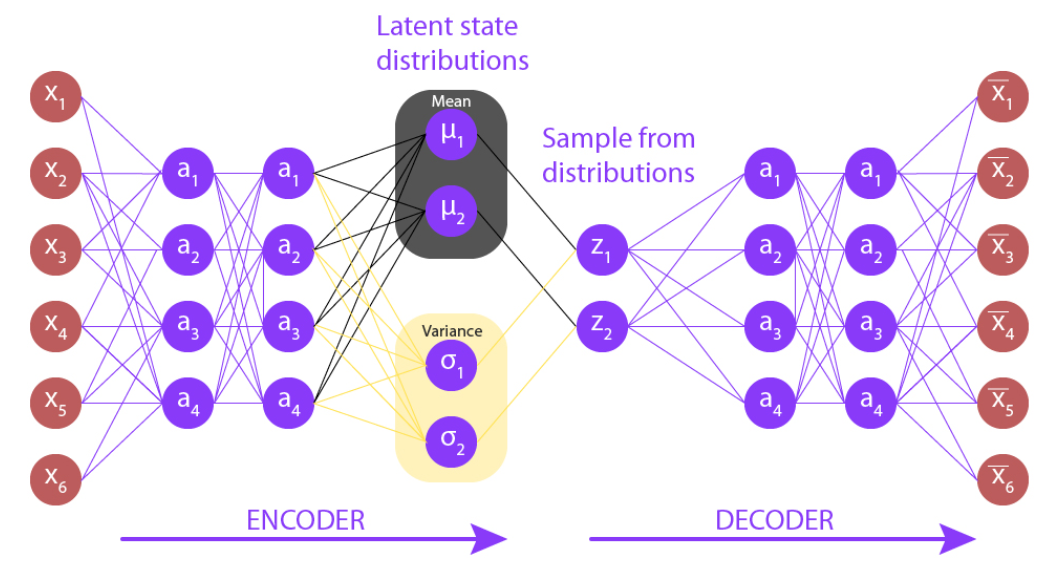

In [ ]:
# ACTUAL MODEL(ENCODER + DECODER)
class DefectCVAE(nn.Module):
    def __init__(self, node_dim, mask_dim, edge_dim, u_dim, hidden_dim, latent_dim):
        super().__init__()
        self.node_dim   = node_dim
        self.mask_dim   = mask_dim
        
        self.encoder = EncoderPart(node_dim, edge_dim, u_dim, latent_dim)
        # self.encoder = CVAE_Encoder(node_dim, edge_dim, u_dim, hidden_dim, latent_dim)
        self.decoder = DecoderPart(latent_dim, mask_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, data):
        mu, log_var = self.encoder(data)
        
        if self.training:
            z = self.reparameterize(mu, log_var)
        else:
            z = mu

        out_decoder = self.decoder(z, data.u, data.pristine_mask, data.pristine_edges, data.pristine_features)
            
        return out_decoder, mu, log_var

# Test with first batch from loader
# for batch in full_train_loader:
the_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for batch in high_train_loader:
    the_sample = batch

    MAX = the_sample.x.shape[0]

    # Test full model
    test_model = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    out, mu, log_var = test_model(the_sample)
    break

## Loss Function

In [ ]:
class LossFN(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.num_defects_loss = nn.MSELoss()
        self.site_loss_fn = nn.BCEWithLogitsLoss()
        self.type_loss_fn = nn.CrossEntropyLoss()
        self.margin = margin

        # Weights
        self.w_count = 1/50


    def site_ranking_loss(self, site_logits, target_sites):
        site_scores = site_logits.squeeze(1)
        positive_scores = site_scores[target_sites == 1]
        negative_scores = site_scores[target_sites == 0]

        differences = (positive_scores.unsqueeze(1) - negative_scores.unsqueeze(0))

        ranking_loss = torch.relu(self.margin - differences)

        return ranking_loss.mean()
        

    def forward(self, model_output, mu, log_var, y, ref_mask, beta, device):

        y = y.to(device)
        ref_mask = ref_mask.to(device)

        # Predictions 
        pred_num_vacs = model_output[0].to(device)
        pred_num_subs = model_output[1].to(device)
        pred_site_logits = model_output[2].to(device)
        pred_type_logits = model_output[3].to(device)
        mu = mu.to(device)
        log_var = log_var.to(device)

        
        # Targets
        target_sites = y[:, :1].squeeze(-1).to(dtype=torch.float)
        target_defective_indices = torch.where(target_sites == 1)[0]

        species_targets = torch.argmax(y[:, 1:], dim=1)
        species_targets = target_look(ref_mask, true_z=species_targets)

        target_num_vacs = (species_targets == 1).sum().float().view_as(pred_num_vacs).to(device)
        target_num_subs = (species_targets == 2).sum().float().view_as(pred_num_subs).to(device)

        clean_species_targets = species_targets - 1        

        target_types = clean_species_targets[target_defective_indices].to(device) 

        # =====================
        # Defects Count Loss
        # =====================
        
        vacs_num_loss = self.num_defects_loss(25.0 * torch.sigmoid(pred_num_vacs), target_num_vacs)
        weighted_vacs_num_loss = self.w_count * vacs_num_loss

        subs_num_loss = self.num_defects_loss(25.0* torch.sigmoid(pred_num_subs), target_num_subs)
        weighted_subs_num_loss = self.w_count * subs_num_loss

        # =====================
        # Site Loss
        # =====================

        # site_loss = self.site_loss_fn(pred_site_logits, target_sites.unsqueeze(1))
        site_loss = self.site_ranking_loss(pred_site_logits,target_sites)
        
        # ======================
        # Species Loss
        # ======================

        pred_types = pred_type_logits[target_defective_indices]

        type_loss = self.type_loss_fn(pred_types, target_types)

        # ======================
        # KL Loss
        # ======================

        kl_loss = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())

        # ======================
        # Total Loss
        # ======================

        total = weighted_vacs_num_loss + weighted_subs_num_loss + site_loss + type_loss + (beta * kl_loss)
        
        return (total, weighted_vacs_num_loss, weighted_subs_num_loss, site_loss, type_loss, kl_loss)

# Test loss function
# for a_batch in full_train_loader:
the_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


for a_batch in high_train_loader:
    test_model = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM)
    out, mu, log_var = test_model(a_batch)

    the_loss_fn = LossFN()
    out_loss = the_loss_fn(out, mu, log_var, a_batch.y, a_batch.pristine_mask, 1e-3, the_device)
    print(out_loss)
    # print(f"total: {a}, defects_count_loss: {e}, species_loss: {c}, kl_loss: {d}")

    break

In [ ]:
def diagnose_loss_scales(model, loader, cvae_loss, device, n_batches=100):
    model.eval()
    records = {
        "total_loss": [], "vacs_num_loss": [], "subs_num_loss": [],
        "site_loss": [], "type_loss": [], "kl_loss": []
    }

    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= n_batches:
                break
            batch = batch.to(device)
            out, mu, log_var = model(batch)
            # beta=1.0 here just so we can see the RAW kl magnitude, unscaled
            out_the_loss = cvae_loss(out, mu, log_var, batch.y, batch.pristine_mask, beta=1.0, device=device)
            records["total_loss"].append(out_the_loss[0].item())
            records["vacs_num_loss"].append(out_the_loss[1].item())
            records["subs_num_loss"].append(out_the_loss[2].item())
            records["site_loss"].append(out_the_loss[3].item())
            records["type_loss"].append(out_the_loss[4].item())
            records["kl_loss"].append(out_the_loss[5].item())

    print(f"{'Loss term':25s} {'mean':>10s} {'std':>10s} {'min':>10s} {'max':>10s}")
    for k, v in records.items():
        v = np.array(v)
        print(f"{k:25s} {v.mean():10.4f} {v.std():10.4f} {v.min():10.4f} {v.max():10.4f}")

    return records

device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
train_loader = high_train_loader 
cvae_loss = LossFN()

raw_scales = diagnose_loss_scales(model, train_loader, cvae_loss, device, n_batches=200)

## Training and Validating

In [ ]:
# Training Function
def train_model(model, train_loader, cvae_loss, current_beta, device, optimizer):
    # Set the model in training mode
    model.train()

    # To track the losses
    losses = [[],[],[],[],[],[]]

    for batch in tqdm(train_loader, leave=False):
        optimizer.zero_grad()

        # Output of the model
        batch = batch.to(device)
        out_train, mu, log_var = model(batch)
        
        # NUM_SITES = batch.x.shape[0]
        # gen_structure_tensor = recon.view((NUM_SITES, (1 + MASK_DIM)))

        # The loss (pass batch.mask and configured weight_penalty)
        out_trian_loss = cvae_loss(out_train, mu, log_var,batch.y, batch.pristine_mask, current_beta, device)
        
        if torch.isnan(out_trian_loss[0]).any():
            print("Found an NaN value")
            break
        
        out_trian_loss[0].backward()
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        for i, j in enumerate(out_trian_loss):
            losses[i].append(j.item() *batch.num_graphs)
        

    n = len(train_loader)
    t_losses = {
        "Total_loss": sum(losses[0])/n, 
        "Vacancy_Count_loss": sum(losses[1])/n,
        "Substitution_Count_loss": sum(losses[2])/n, 
        "Defect_Site_loss": sum(losses[3])/n,
        "Defect_Type_loss": sum(losses[4])/n, 
        "KL_loss": sum(losses[5])/n, 
    }

    return t_losses

def validate_model(model, val_loader, cvae_loss, current_beta, device):
    # Model in evaluation mode
    model.eval()
    
    # t_loss, c_loss, sp_loss, kl_loss = 0.0, 0.0, 0.0, 0.0
    losses = [[],[],[],[],[],[]]

    with torch.no_grad():
        for batch in tqdm(val_loader, leave=False):
            batch = batch.to(device)
            out_val, mu, log_var = model(batch)
            # NUM_SITES = batch.x.shape[0]
            # recon = recon.view((NUM_SITES,(1 + MASK_DIM)))

            out_val_loss = cvae_loss(out_val, mu, log_var, batch.y, batch.pristine_mask, current_beta, device)
            if torch.isnan(out_val_loss[0]).any():
                print("Found an NaN value")
                break

            for i, j in enumerate(out_val_loss):
                losses[i].append(j.item() * batch.num_graphs)

        n = len(val_loader)# .dataset)
        v_losses = {
            "Total_loss": sum(losses[0])/n, 
            "Vacancy_Count_loss": sum(losses[1])/n,
            "Substitution_Count_loss": sum(losses[2])/n, 
            "Defect_Site_loss": sum(losses[3])/n,
            "Defect_Type_loss": sum(losses[4])/n, 
            "KL_loss": sum(losses[5])/n, 
            }

        return v_losses



# Loaders for Full Dataset
# train_loader = full_train_loader 
# val_loader = full_val_loader 

# Loaders for Sample Dataset
train_loader = high_train_loader 
val_loader = high_val_loader 

# Parameters for training model
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DefectCVAE(NODE_DIM, MASK_DIM, EDGE_DIM, U_DIM, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
cvae_loss = LossFN()

EPOCHS = 15
beta   = 1e-3

train_metrics, val_metrics = [], []


for epoch in range(1, EPOCHS+1):
    print(f"Epoch {epoch:4d}")
    # Train
    current_beta = beta * min(1.0, epoch / EPOCHS)
    t_losses = train_model(model,train_loader, cvae_loss, current_beta, device, optimizer)

    # Validate
    val_losses = validate_model(model, val_loader, cvae_loss, current_beta, device)
    scheduler.step()

    # Store and print metrics
    train_metrics.append(t_losses)
    val_metrics.append(val_losses)

    print("TRAINING LOSSES")

    train_loss_types = list(t_losses.keys())
    train_loss_values = list(t_losses.values())

    for i, j in zip(train_loss_types, train_loss_values):
        print(f"\t{i} : {j:.4f}")

    print("\nVALIDATING LOSSES")

    val_loss_types = list(val_losses.keys())
    val_loss_values = list(val_losses.values())

    for i, j in zip(val_loss_types, val_loss_values):
        print(f"\t{i} : {j:.4f}")
    

In [ ]:
training_losses = []
validating_losses = []

valuess = list(train_metrics[0].keys())   

for i in valuess:
    the_train_loss = []
    for j in range(len(train_metrics)):
        the_train_loss.append(train_metrics[j][i])
    training_losses.append(the_train_loss)

    the_val_loss = []
    for j in range(len(val_metrics)):
        the_val_loss.append(val_metrics[j][i])
    validating_losses.append(the_val_loss)

In [ ]:
titles = list(train_metrics[0].keys())   

variabless = len(titles)

fig, axes = plt.subplots(variabless, 1, figsize=(10, 15))

axes_flat = axes.flatten()

for title, trains, vals, ax in zip(titles, training_losses, validating_losses, axes_flat):
    ax.plot(trains, label='Training')
    ax.plot(vals, label='validating')
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

## Inverse Design

In [ ]:
import gnn_models
import graphy_gnn

# Load Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# the_model = gnn_models.GNNModel1().to(device)
the_model = gnn_models.AI4matPart(26, 14, 6, embed_dim=32, num_blocks=3).to(device)
model_path = "Final_Dataset/gnn models/megnet_model.pth"
the_model.load_state_dict(torch.load(model_path))


In [ ]:

# Make Prediction
def add_bond_batch(graph):
    for data in graph:
        bond_batch = torch.zeros((1, data.edge_index.shape[1]))
        data.bond_batch = bond_batch.squeeze(0).to(dtype=torch.long)

    return graph 

def modify_x_global(graph):
    for data in graph:
        new_x = data.x[...,1:]

        all_u = data.u.squeeze(0)
        keep_indices = torch.tensor([0,1,8,11,12,13])
        new_u = torch.index_select(all_u, dim=0, index=keep_indices)
        
        data.x = new_x
        data.u = new_u.unsqueeze(0)
    return graph

def predict_bgv(the_model, device, original_structure, generated_structure, tbgv):

    # Prepare Generated Structure
    defective_structure = get_clean_defective(generated_structure)

    defects_structure = graphy_gnn.get_defects_structure(defective_structure, original_structure)

    nodes = graphy_gnn.get_nodes(defects_structure)
    edges, edge_features = graphy_gnn.get_edges_and_features(original_structure, defects_structure)
    global_features = graphy_gnn.get_globals(original_structure, defective_structure, defects_structure)
    target = tbgv
    # p_edges = get_pristine_edges(original_structure)

    the_data = Data(
        x=torch.tensor(nodes, dtype=torch.float),
        edge_index=torch.tensor(edges, dtype=torch.long),
        edge_attr=torch.tensor(edge_features, dtype=torch.float),
        u=torch.tensor(global_features, dtype=torch.float).unsqueeze(0),
        y=torch.tensor(target, dtype=torch.float).unsqueeze(0),
        # pristine_edges=torch.tensor(p_edges, dtype=torch.long)
    )

    the_data = modify_x_global(add_bond_batch([the_data]))

    attempt = DataLoader(the_data, batch_size=1, shuffle=False)

    # Make prediction
    the_prediction, the_target = gnn_models.predict(the_model, attempt, device)
    print(f"Predicted Band Gap: {the_prediction[0]}")
    # print(f"Target Band Gap: {the_target[0]}")
    
def gen_tensor(model, reference_structure, target_band_gap, device = "cpu"):
    model.eval()
    model.to(device)

    with torch.no_grad():
        # the_lattice = reference_structure.lattice
        ref_material = reference_structure.reduced_formula
        out_sites = len(reference_structure)
    
        condition = get_globals(ref_material, target_band_gap)
        
        the_z = torch.randn(1, 32, device=device)
        the_condition = torch.tensor(condition*1, dtype=torch.float).unsqueeze(0).to(device=device)
        the_pristine_mask = torch.tensor(get_pristine_mask(reference_structure), dtype=torch.long)
        the_pristine_edges = torch.tensor(get_pristine_edges(reference_structure), dtype=torch.long)
        the_pristine_features = torch.tensor(get_site_features(reference_structure), dtype=torch.float)
        
        # Generated Edge Indices
        '''nodes = [i for i in range(out_sites)]
        nodes = [nodes for _ in range(out_sites)]
        adj = torch.tensor(nodes, dtype=torch.float)
        the_edge_index, edge_attr = dense_to_sparse(adj)'''
    
        # Run decoder
        # (num_vacants, num_subs, site_logits, type_logits)
        out_gen = model.decoder(the_z, the_condition, the_pristine_mask, the_pristine_edges, the_pristine_features)
        # defective_tensors = defective_tensors.view((out_sites, (1 + self.mask_dim)))

    return (out_gen, the_pristine_mask)


def get_clean_defective(full_defective_structure, save=False):
    all_elements = [Element.from_Z(z) for z in range(1, 119)]

    unwanted_sites_index = []

    idx = 0
    
    for site in full_defective_structure.sites:
        if site.specie not in all_elements:
            unwanted_sites_index.append(idx)
        idx += 1
    
    new_defective_structure = full_defective_structure.remove_sites(unwanted_sites_index)

    if save:
        writer = CifWriter(new_defective_structure)
        writer.write_file(f"Final_Dataset/cvae models/Generated_Structures/{new_defective_structure.formula}.cif")

    return new_defective_structure

def get_visualization(full_defective_structure, pristine_structure):
    
    cloud = get_cloud(full_defective_structure, pristine_structure)

    defective = get_clean_defective(full_defective_structure)

    # if vis:
    fig, num = plt.subplots(1,3, figsize=(15,5))
    # Visualize the pristine structure
    new_pristine = AseAtomsAdaptor.get_atoms(pristine_structure)
    plot_atoms(new_pristine, num[0])
    num[0].set_title("Structure without defects")

    # Visualize the defective structure
    new_defective = AseAtomsAdaptor.get_atoms(defective)
    plot_atoms(new_defective, num[1])
    num[1].set_title("Structure with defects")

    # Visualize the structure without defects
    new_cloud = AseAtomsAdaptor.get_atoms(cloud)
    plot_atoms(new_cloud, num[2])
    num[2].set_title("Defects only structure")

comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

def test_from_df(the_material):

    sample_df = comb_df[comb_df["dataset_material"] == f"high_{the_material}"]
    
    choose_sample = random.randint(0,len(sample_df)-1)

    sample_row = sample_df.iloc[choose_sample]

    # Get required attributes from sample row
    sample_dataset_material = sample_row["dataset_material"]
    sample_id = sample_row["_id"]

    # Get defective structure
    clean_defective_path = f"original_dataset/{sample_dataset_material}/cifs/{sample_id}.cif"
    clean_defective_structure = Structure.from_file(clean_defective_path)

    # Get reference structure
    pristine_path = f"Final_Dataset/ref_cifs/{sample_dataset_material}.cif"
    pristine_structure = Structure.from_file(pristine_path)

    # Get Full Defective Structure
    full_defective_structure  = get_full_defective(pristine_structure, clean_defective_structure)

    sample_bgv = sample_row["band_gap_value"]
    print(f"Target Band Gap  : {sample_bgv}\n")

    print("TARGET STRUCTURE")
    print(f"Structure Formula: {full_defective_structure.formula}")

    sample_defects_count = sample_row["defect_sites"]
    print(f"Defects Count    : {sample_defects_count}\n")

    out_gen = gen_tensor(model, pristine_structure, sample_bgv, "cpu")
    generated_structure = gen_structure(pristine_structure, out_gen[1], out_gen[0])

    print("PREDICTED STRUCTURE")
    print(f"Structure Formula: {generated_structure.formula}")

    gen_cloud = get_cloud(generated_structure, pristine_structure)
    print(f"Defects Count    : {len(gen_cloud)}")


    return pristine_structure, full_defective_structure, generated_structure, sample_bgv

In [ ]:
# uncomment a line with a material to generate a structure
original_structure, target_structure, generated_structure, tbgv = test_from_df("GaSe")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("InSe")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("BN")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("P")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("WSe2")
# original_structure, target_structure, generated_structure, tbgv = test_from_df("MoS2")

# the_cloud = get_cloud(generated_structure, original_structure)

print("\nThe Standard Structure")
get_visualization(target_structure, original_structure)

print("The Generated Structure")
get_visualization(generated_structure, original_structure)

print("\nBAND GAP OF GENERATED STRUCTURE")
predict_bgv(the_model, device, original_structure, generated_structure, tbgv)


# Current Issue and Request for Feedback

I am currently stuck on an issue with the defect generation part of the model, and I would appreciate your feedback on where the problem might be coming from.

## 1. Observed Problem

There are two main issues with the structures generated by the model:

1. **The model repeatedly predicts the same type of defect.**
   Instead of generating a mixture of the two possible defect types (vacancies and substitutions), the generated structures tend to contain only one type of defect.

2. **The model predicts defect sites in similar regions of the structure.**
   Rather than selecting defect sites that are distributed across different regions of the structure, the predicted defect locations tend to be concentrated in the same or nearby regions.

To observe this behavior, the last code cell in the notebook can be rerun multiple times and the generated structures can be compared.

Each time the cell is run, the model is given a different target band gap value, so the repeated behavior is **not** due to asking the model to generate the same structure for exactly the same band gap. Despite the changing target band gap, the same general issues with defect type selection and defect site selection can still be observed.

---

## 2. Training and Validation Losses

The losses obtained during training are shown below:

| Epoch | Split      | Total Loss | Vacancy Count Loss | Substitution Count Loss | Defect Site Loss | Defect Type Loss |  KL Loss |
| ----: | ---------- | ---------: | -----------------: | ----------------------: | ---------------: | ---------------: | -------: |
|     1 | Training   |     9.2465 |             3.3524 |                  4.1426 |           1.0001 |           0.6954 | 280.4959 |
|     1 | Validation |     5.2479 |             2.2028 |                  1.3476 |           1.0001 |           0.6937 |  18.9348 |
|     2 | Training   |     4.9326 |             1.6599 |                  1.5698 |           1.0001 |           0.6935 |  23.4261 |
|     2 | Validation |     7.2002 |             3.3255 |                  2.1668 |           1.0000 |           0.6939 |  34.8991 |
|     3 | Training   |     4.8359 |             1.6232 |                  1.5029 |           1.0000 |           0.6937 |  26.9857 |
|     3 | Validation |     5.1746 |             2.0163 |                  1.4502 |           1.0000 |           0.6932 |  24.8750 |
|     4 | Training   |     4.6937 |             1.6239 |                  1.3575 |           1.0000 |           0.6935 |  23.5939 |
|     4 | Validation |     4.3966 |             1.4861 |                  1.1974 |           1.0002 |           0.6931 |  24.8249 |
|     5 | Training   |     4.6965 |             1.6425 |                  1.3399 |           1.0001 |           0.6934 |  20.5238 |
|     5 | Validation |     4.4705 |             1.5701 |                  1.1879 |           1.0001 |           0.6931 |  19.2760 |

---

## 3. Why I Suspect the Site and Type Prediction Components

From the training results, the vacancy count and substitution count losses decrease significantly compared with their initial values. This suggests that the model is learning something about **how many** vacancies and substitutions should be present.

However, the **Defect Site Loss** and **Defect Type Loss** show a very different pattern.

### Defect Site Loss

The defect site loss remains almost exactly constant throughout training and validation:

* Training: approximately **1.0000**
* Validation: approximately **1.0000**

The defect site prediction is responsible for choosing **where in the structure a defect should be placed**.

Since this loss remains essentially unchanged during training, my concern is that this part of the model may not be learning effectively. This could potentially explain why the generated defects tend to appear repeatedly in the same regions instead of being distributed more appropriately across the structure.

### Defect Type Loss

Similarly, the defect type loss remains almost constant:

* Training: approximately **0.6934–0.6954**
* Validation: approximately **0.6931–0.6939**

The defect type prediction is responsible for deciding **which type of defect should be placed at a selected site**, i.e., whether the defect is a:

* Vacancy, or
* Substitution.

The fact that this loss also remains almost unchanged throughout training makes me suspect that the model may not be learning this classification task effectively. This could explain why the generated structures repeatedly contain the same defect type instead of a mixture of vacancies and substitutions.

---

## 4. Current Interpretation

Based on the generated structures and the loss behavior, my current hypothesis is that the main problem is in the **defect site prediction and/or defect type prediction parts of the model**.

In particular:

* The model appears to learn the predicted **number of vacancies and substitutions** to some extent, since those losses decrease.
* However, the model does not appear to improve noticeably in learning **where to place the defects**, since the defect site loss stays close to 1.0.
* The model also does not appear to improve noticeably in learning **which type of defect to place at a given site**, since the defect type loss stays close to 0.693.

Because these two losses remain nearly constant across all five epochs, I suspect there may be an issue with one or more of the following:



---

## 5. Where I Am Currently Stuck

This is the part of the project where I have been stuck for quite a long time.

The model is producing outputs and the total loss decreases, but the actual generated structures still show the two behaviors described above:

1. The same defect type is repeatedly selected.
2. Defect sites tend to be concentrated in the same regions.

At this point, I would really appreciate feedback on whether the nearly constant **Defect Site Loss (~1.0)** and **Defect Type Loss (~0.693)** suggest a problem with the implementation of these prediction heads or their loss functions, or whether there may be another issue earlier in the data preparation, target construction, or generation pipeline that could explain this behavior.

I believe identifying why these two losses remain essentially unchanged is likely important for understanding why the generated defect sites and defect types do not show the expected diversity.
